# Cohort Analysis Project

Bu layihədə `sales.csv` datasından istifadə edərək aylıq və həftəlik `cohort analysis` aparacaqsınız. Analiz zamanı `cohort`, `lifetime`, `retention`, `churn`, `revenue` və `ARPU` anlayışlarından istifadə ediləcək.

Notebook-da hazır kod və cavab yoxdur. Task-ları ardıcıllıqla yerinə yetirin və nəticələri uyğun code və Markdown cell-lərində təqdim edin.

## 1. Data Overview və Data Cleaning

### Task 1. Data Overview

Lazım olan kitabxanaları import edin, `sales.csv` faylını yükləyin və datasetlə ümumi tanışlıq aparın. Datanın strukturu, ölçüsü və məzmunu haqqında qısa nəticə yazın.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/sales.csv')
# Structure
print('SHAPE:', df.shape)
print('COLUMNS:', list(df.columns))
print(df.dtypes)
print(df.head(10))

# Data quality
print('NULLS:')
print(df.isnull().sum())
print('DUPLICATES:', df.duplicated().sum())

# Content overview
print('Order date range:', df['order_date'].min(), '-', df['order_date'].max())
print(df['status'].value_counts())
print(df['category'].value_counts())
print(df['payment_method'].value_counts())
print(df['Region'].value_counts())
print('Unique orders:', df['order_id'].nunique())
print('Unique customers:', df['cust_id'].nunique())
print(df[['qty_ordered', 'price', 'discount_amount', 'age']].describe())

/tmp/ipykernel_555/605485640.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Python Final Projects/Cohort Analysis/sales.csv')


SHAPE: (286392, 33)
COLUMNS: ['order_id', 'order_date', 'status', 'item_id', 'sku', 'qty_ordered', 'price', 'discount_amount', 'category', 'payment_method', 'bi_st', 'cust_id', 'year', 'month', 'ref_num', 'Name Prefix', 'First Name', 'Middle Initial', 'Last Name', 'Gender', 'age', 'full_name', 'E Mail', 'Customer Since', 'SSN', 'Phone No. ', 'Place Name', 'County', 'City', 'State', 'Zip', 'Region', 'User Name']
order_id            object
order_date          object
status              object
item_id              int64
sku                 object
qty_ordered          int64
price              float64
discount_amount    float64
category            object
payment_method      object
bi_st               object
cust_id              int64
year                 int64
month               object
ref_num              int64
Name Prefix         object
First Name          object
Middle Initial      object
Last Name           object
Gender              object
age                  int64
full_name         

### Task 2. Data Cleaning

Cohort analysis üçün lazım olan sütunları saxlayın və datada ümumi cleaning işləri aparın. Missing value və duplicate sətirləri birlikdə yoxlayın, uyğun təmizləmə qərarları verin və sonda təmiz datanın vəziyyətini göstərin.

> **Tip:** `status` sütununu nəzərə alın. Cancellation, refund və tamamlanmamış sifarişlərin uğurlu alış kimi hesablanıb-hesablanmamasına qərar verin.

In [17]:
# Order date ve customer since datasi duzgun saxlanilmayib, formati date-e deyishmek lazimdir
df['order_date']=pd.to_datetime(df['order_date'],format="%d-%m-%Y")

print(df['order_date'].min())
print(df['order_date'].max())

# Customer Since sutununda tarixler slash, tire ve noqteyle ayrilib, bunlari eynilesdirmeliyik (hamisi - ile)
df['Customer Since'] = df['Customer Since'].str.replace('/', '-', regex=False)
df['Customer Since'] = df['Customer Since'].str.replace('.', '-', regex=False)

#indi ise date formatina deyismek lazimdir, amma daha once month ve ya days once geldiyini mueyyen etmeliyik
mask = df['Customer Since'].astype(str).str.contains('-', na=False)
parts = df.loc[mask, 'Customer Since'].str.split('-', expand=True)


print('Max first part:', parts[0].astype(int).max())
print('Max second part:', parts[1].astype(int).max())

# 1ci month daha sonra days gelir, indi formati deyise bilerik
df['Customer Since']=pd.to_datetime(df['Customer Since'],format="%m-%d-%Y")


2020-10-01 00:00:00
2021-09-30 00:00:00
Max first part: 12
Max second part: 31


In [18]:
# Burda status sutunun revize edirik, ayrica order_outcome sutunu yaradib, statusa gore orderin successfull, cancelled ve ya refunded oldugunu teyin edirik
successful = ['complete', 'closed', 'paid', 'cod', 'received']
cancelled  = ['canceled', 'holded', 'payment_review', 'pending', 'pending_paypal', 'processing']
refunded   = ['order_refunded', 'refund']

df['order_outcome'] = 'unknown'
df.loc[df['status'].isin(successful), 'order_outcome'] = 'successful'
df.loc[df['status'].isin(cancelled), 'order_outcome']  = 'cancelled'
df.loc[df['status'].isin(refunded), 'order_outcome']   = 'refunded'

print(df['order_outcome'].value_counts(normalize=True).mul(100).round(1))

# Satış analizi üçün yalnız uğurlu sifarişləri saxlamaq istesek:
df_sales = df[df['order_outcome'] == 'successful'].copy()

order_outcome
successful    50.5
cancelled     39.2
refunded      10.3
Name: proportion, dtype: float64


### Task 3. Revenue

Hər sifariş sətri üçün `revenue` dəyişəni yaradın və nəticəni yoxlayın.

> **Tip:** Hesablamada `qty_ordered`, `price` və `discount_amount` sütunlarından istifadə edin.

In [19]:
df['revenue'] = df['qty_ordered'] * df['price'] - df['discount_amount']
df

# Satış analizi üçün yalnız uğurlu sifarişləri saxlamaq istesek:
df_sales = df[df['order_outcome'] == 'successful'].copy()

## 2. Aylıq cohort analysis

### Task 4. First order date

Hər customer-in ilk sifariş tarixini hesablayın və bu məlumatı əsas `orders` dataframe-inə əlavə edin.

In [20]:
# Hər müştərinin ilk sifariş tarixini tapmaq ucun, cust_id-e gore qruplara boluruk


first_order = df_sales.groupby('cust_id')['order_date'].min().reset_index()
first_order.columns = ['cust_id', 'first_order_date']

df_sales = df_sales.merge(first_order, on='cust_id', how='left')

df_sales

,order_id,order_date,status,item_id,sku,qty_ordered,price,discount_amount,category,payment_method,...,Place Name,County,City,State,Zip,Region,User Name,order_outcome,revenue,first_order_date
0,100354678,2020-10-01,received,574772,oasis_Oasis-064-36,21,89.9,0.0,Men's Fashion,cod,...,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,successful,1887.9,2020-10-01
1,100354678,2020-10-01,received,574774,Fantastic_FT-48,11,19.0,0.0,Men's Fashion,cod,...,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,successful,209.0,2020-10-01
2,100354680,2020-10-01,complete,574777,mdeal_DMC-610-8,9,149.9,0.0,Men's Fashion,cod,...,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,successful,1349.1,2020-10-01
3,100354680,2020-10-01,complete,574779,oasis_Oasis-061-36,9,79.9,0.0,Men's Fashion,cod,...,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,successful,719.1,2020-10-01
4,100367357,2020-11-13,received,595185,MEFNAR59C38B6CA08CD,2,99.9,0.0,Men's Fashion,cod,...,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,successful,199.8,2020-10-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144521,100562352,2021-09-30,paid,905161,BAGKEM5A703890E559C,2,57.2,0.0,Beauty & Grooming,bankalfalah,...,Acworth,Sullivan,Acworth,NH,3601,Northeast,dovan,successful,114.4,2021-09-30
144522,100562365,2021-09-30,paid,905179,APPCHA5AF14939B8F8A,2,4419.9,0.0,Appliances,Easypay,...,Rushville,Yates,Rushville,NY,14544,Northeast,bklatham,successful,8839.8,2021-09-30
144523,100562376,2021-09-30,cod,905191,MEFCOT5A8D1E973B886,2,39.9,0.0,Men's Fashion,cod,...,Lawrenceville,Gwinnett,Lawrenceville,GA,30044,South,bmbrunetti,successful,79.8,2021-09-30
144524,100562383,2021-09-30,cod,905200,WOFVAL59D5EA84167F9-M,2,40.0,0.0,Women's Fashion,cod,...,Durham,Durham,Durham,NC,27701,South,fngiusti,successful,80.0,2021-09-30


### Task 5. Aylıq period-lar

Customer-in ilk sifariş ayını və hər sifarişin baş verdiyi ayı göstərən dəyişənlər yaradın. Datasetdə neçə fərqli aylıq cohort olduğunu müəyyən edin.

> **Tip:** Tarixləri monthly period formatına çevirmək üçün `.dt.to_period('M')` istifadə edə bilərsiniz.

In [21]:
# Müştərinin ilk sifariş ayı (cohort)

df_sales['cohort_month'] = df_sales['first_order_date'].dt.to_period('M')

In [22]:
# Musterinin cari sifaris ayi
df_sales['order_month'] = df_sales['order_date'].dt.to_period('M')
df_sales

,order_id,order_date,status,item_id,sku,qty_ordered,price,discount_amount,category,payment_method,...,City,State,Zip,Region,User Name,order_outcome,revenue,first_order_date,cohort_month,order_month
0,100354678,2020-10-01,received,574772,oasis_Oasis-064-36,21,89.9,0.0,Men's Fashion,cod,...,Vinson,OK,73571,South,jwtitus,successful,1887.9,2020-10-01,2020-10,2020-10
1,100354678,2020-10-01,received,574774,Fantastic_FT-48,11,19.0,0.0,Men's Fashion,cod,...,Vinson,OK,73571,South,jwtitus,successful,209.0,2020-10-01,2020-10,2020-10
2,100354680,2020-10-01,complete,574777,mdeal_DMC-610-8,9,149.9,0.0,Men's Fashion,cod,...,Vinson,OK,73571,South,jwtitus,successful,1349.1,2020-10-01,2020-10,2020-10
3,100354680,2020-10-01,complete,574779,oasis_Oasis-061-36,9,79.9,0.0,Men's Fashion,cod,...,Vinson,OK,73571,South,jwtitus,successful,719.1,2020-10-01,2020-10,2020-10
4,100367357,2020-11-13,received,595185,MEFNAR59C38B6CA08CD,2,99.9,0.0,Men's Fashion,cod,...,Vinson,OK,73571,South,jwtitus,successful,199.8,2020-10-01,2020-10,2020-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144521,100562352,2021-09-30,paid,905161,BAGKEM5A703890E559C,2,57.2,0.0,Beauty & Grooming,bankalfalah,...,Acworth,NH,3601,Northeast,dovan,successful,114.4,2021-09-30,2021-09,2021-09
144522,100562365,2021-09-30,paid,905179,APPCHA5AF14939B8F8A,2,4419.9,0.0,Appliances,Easypay,...,Rushville,NY,14544,Northeast,bklatham,successful,8839.8,2021-09-30,2021-09,2021-09
144523,100562376,2021-09-30,cod,905191,MEFCOT5A8D1E973B886,2,39.9,0.0,Men's Fashion,cod,...,Lawrenceville,GA,30044,South,bmbrunetti,successful,79.8,2021-09-30,2021-09,2021-09
144524,100562383,2021-09-30,cod,905200,WOFVAL59D5EA84167F9-M,2,40.0,0.0,Women's Fashion,cod,...,Durham,NC,27701,South,fngiusti,successful,80.0,2021-09-30,2021-09,2021-09


### Task 6. Cohort summary

Hər aylıq cohort üzrə unique order, unique customer və total revenue göstəricilərini hesablayın. Nəticəni tarix ardıcıllığı ilə təqdim edin.

In [23]:
# Cohort summary

cohort_monthly=df_sales.groupby('cohort_month').agg(
    unique_orders = ('order_id','nunique'),
    unique_customers = ('cust_id','nunique'),
    total_revenue = ('revenue','sum')
).reset_index().sort_values('cohort_month')

cohort_monthly

,cohort_month,unique_orders,unique_customers,total_revenue
0,2020-10,7991,1865,1.213271e+07
1,2020-11,8219,2556,1.298621e+07
2,2020-12,35266,14131,7.352192e+07
3,2021-01,4109,2361,3.738258e+06
4,2021-02,3276,1409,2.507074e+06
5,2021-03,8375,4176,2.050614e+07
6,2021-04,12155,6994,2.227152e+07
7,2021-05,3278,2309,3.192770e+06
8,2021-06,5759,2847,1.275138e+07
9,2021-07,2148,1435,4.505100e+06


### Task 7. Cohort summary visualization

Aylıq cohort-lar üzrə order, customer və revenue göstəricilərini uyğun qrafiklərlə vizuallaşdırın və əsas müşahidələrinizi yazın.

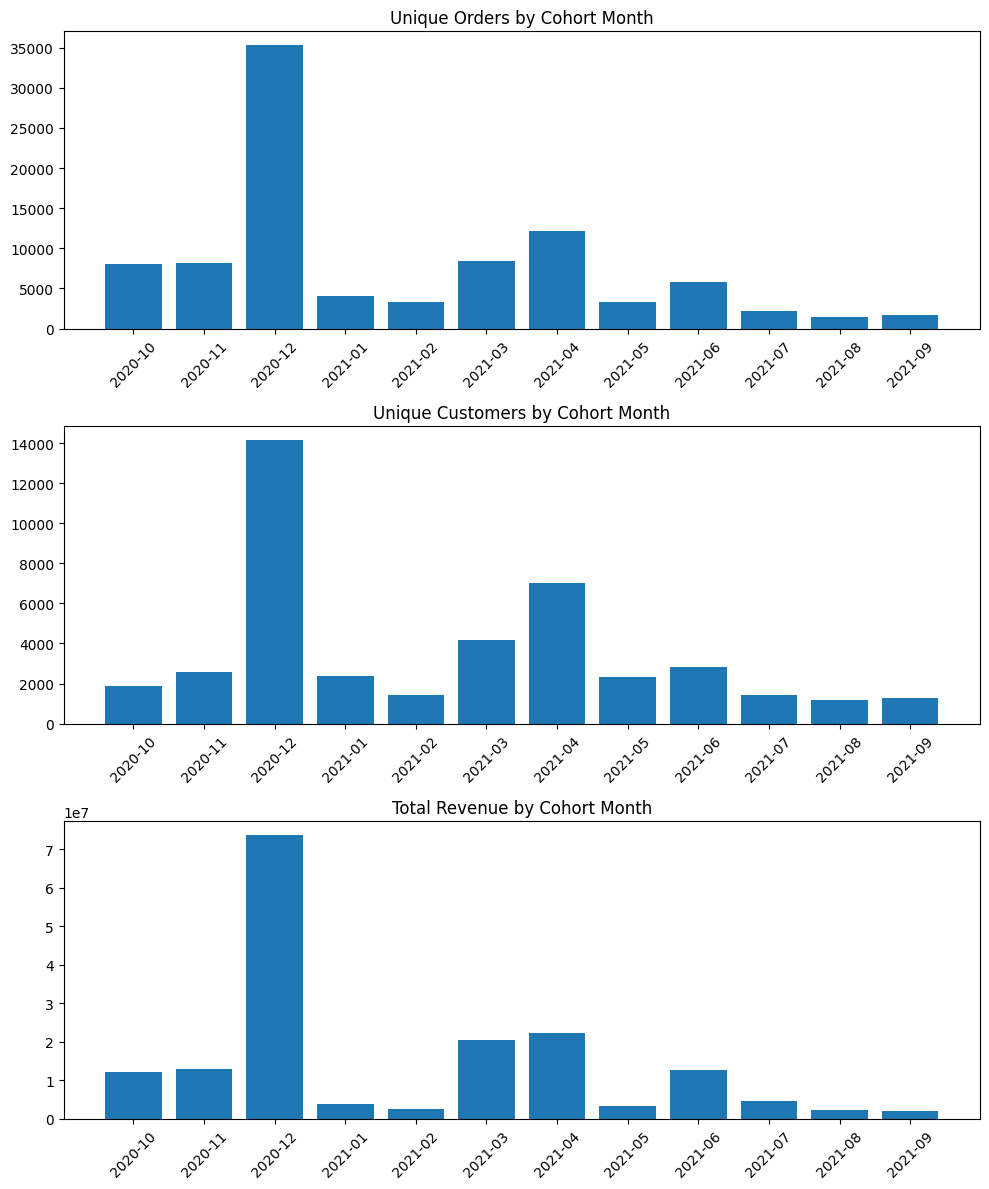

In [24]:
# Cohort summary visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

axes[0].bar(cohort_monthly['cohort_month'].astype(str), cohort_monthly['unique_orders'])
axes[0].set_title('Unique Orders by Cohort Month')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(cohort_monthly['cohort_month'].astype(str), cohort_monthly['unique_customers'])
axes[1].set_title('Unique Customers by Cohort Month')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(cohort_monthly['cohort_month'].astype(str), cohort_monthly['total_revenue'])
axes[2].set_title('Total Revenue by Cohort Month')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Task 8. Customer activity pivot table

Sətirlərdə customer-in ilk sifariş ayı, sütunlarda isə sifariş ayı olacaq şəkildə unique customer saylarını göstərən pivot table yaradın. Nəticəni şərh edin.

In [25]:
cohort_pivot=df_sales.pivot_table(
    index='cohort_month',
    columns='order_month',
    values='cust_id',
    aggfunc='nunique'
)
cohort_pivot

order_month,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09
cohort_month,,,,,,,,,,,,
2020-10,1865.0,315.0,390.0,171.0,124.0,178.0,153.0,89.0,143.0,86.0,54.0,94.0
2020-11,NaN,2556.0,577.0,218.0,139.0,205.0,181.0,109.0,191.0,85.0,48.0,92.0
2020-12,NaN,NaN,14131.0,1022.0,459.0,631.0,681.0,330.0,562.0,263.0,170.0,270.0
2021-01,NaN,NaN,NaN,2361.0,158.0,110.0,111.0,69.0,77.0,63.0,42.0,53.0
2021-02,NaN,NaN,NaN,NaN,1409.0,122.0,95.0,54.0,55.0,33.0,27.0,30.0
2021-03,NaN,NaN,NaN,NaN,NaN,4176.0,524.0,131.0,233.0,83.0,49.0,83.0
2021-04,NaN,NaN,NaN,NaN,NaN,NaN,6994.0,259.0,264.0,95.0,64.0,78.0
2021-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2309.0,162.0,89.0,49.0,45.0
2021-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2847.0,145.0,66.0,101.0


### Task 9. Aylıq cohort metric-ləri

Datanı ilk sifariş ayı və sifariş ayı üzrə qruplaşdıraraq hər qrup üçün total revenue və unique customer sayını hesablayın.

In [26]:
monthly_cohort_metric=df_sales.groupby(['cohort_month','order_month']).agg(
    unique_customers=('cust_id','nunique'),
    total_revenue=('revenue','sum')
    ).reset_index()
monthly_cohort_metric

,cohort_month,order_month,unique_customers,total_revenue
0,2020-10,2020-10,1865,2.378729e+06
1,2020-10,2020-11,315,1.017848e+06
2,2020-10,2020-12,390,3.721181e+06
3,2020-10,2021-01,171,4.121083e+05
4,2020-10,2021-02,124,2.944669e+05
...,...,...,...,...
73,2021-07,2021-08,94,8.742047e+05
74,2021-07,2021-09,58,1.562954e+05
75,2021-08,2021-08,1177,2.136463e+06
76,2021-08,2021-09,65,5.995557e+04


### Task 10. ARPU

Hər aylıq cohort və sifariş ayı üçün ARPU hesablayın. Nəticəni pivot table formasında göstərin.


In [27]:

monthly_cohort_metric['ARPU'] = monthly_cohort_metric['total_revenue'] / monthly_cohort_metric['unique_customers']

arpu_pivot = monthly_cohort_metric.pivot_table(
    index='cohort_month',
    columns='order_month',
    values='ARPU'
)

arpu_pivot.round(2)

order_month,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09
cohort_month,,,,,,,,,,,,
2020-10,1275.46,3231.26,9541.49,2409.99,2374.73,8855.56,8047.84,2418.96,4308.04,2209.00,1720.70,4112.12
2020-11,NaN,1776.31,6304.10,2050.46,2327.90,6531.33,5715.35,2218.99,4144.16,2488.72,1598.48,3726.72
2020-12,NaN,NaN,4056.66,1321.05,2019.16,8169.21,6418.67,1750.45,4487.34,1375.49,1153.96,2729.62
2021-01,NaN,NaN,NaN,1100.68,1068.65,1689.95,2264.55,1936.80,1745.15,2633.95,1071.09,1028.26
2021-02,NaN,NaN,NaN,NaN,973.05,2992.25,2439.30,2353.95,3402.39,2714.33,2015.82,2700.54
2021-03,NaN,NaN,NaN,NaN,NaN,3562.77,6105.77,2605.78,6169.82,2135.07,1140.33,5018.86
2021-04,NaN,NaN,NaN,NaN,NaN,NaN,2821.12,1334.41,5949.40,1638.78,1482.15,4792.74
2021-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1045.11,3036.41,1777.85,1186.03,1585.94
2021-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3799.35,5654.62,9294.04,4963.42


### Task 11. Aylıq cohort lifetime

Hər sifarişin customer-in ilk sifariş ayından neçə ay sonra baş verdiyini göstərən `cohort_lifetime` dəyişəni yaradın. İlk alış ayını lifetime 0 kimi qəbul edin.


In [29]:
df_sales['cohort_lifetime'] = (
    df_sales['order_month'].astype(int)
    - df_sales['cohort_month'].astype(int)
)

### Task 12. ARPU heatmap

Sətirlərdə aylıq cohort, sütunlarda `cohort_lifetime`, dəyər kimi ARPU olan pivot table yaradın və heatmap ilə vizuallaşdırın. Nəticəni şərh edin.

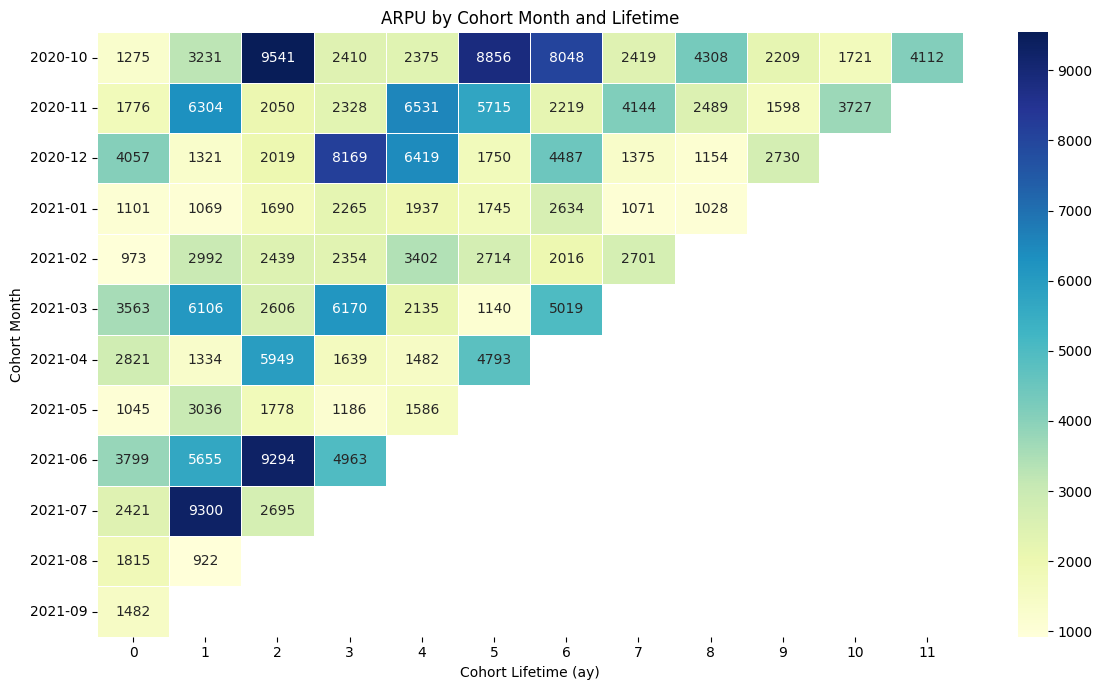

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# cohort_month + cohort_lifetime üzrə ARPU hesablanması
cohort_data = df_sales.groupby(['cohort_month', 'cohort_lifetime']).agg(
    total_revenue=('revenue', 'sum'),
    unique_customers=('cust_id', 'nunique')
).reset_index()
cohort_data['ARPU'] = cohort_data['total_revenue'] / cohort_data['unique_customers']

# Pivot table
arpu_pivot = cohort_data.pivot_table(
    index='cohort_month',
    columns='cohort_lifetime',
    values='ARPU'
)

# Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(arpu_pivot, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('ARPU by Cohort Month and Lifetime')
plt.xlabel('Cohort Lifetime (ay)')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

## 3. Həftəlik retention analysis

### Task 13. Həftəlik period-lar

Hər sifariş üçün sifarişin baş verdiyi həftənin başlanğıc tarixini, hər customer üçün isə ilk alış həftəsinin başlanğıc tarixini hesablayın.


In [32]:
# Sifarişin baş verdiyi həftənin başlanğıcı
df_sales['order_week'] = (
    df_sales['order_date'].dt.to_period('W').dt.start_time
)

# Hər müştəri üçün ilk alış həftəsinin başlanğıcı
first_order_week = (
    df_sales.groupby('cust_id')['order_week']
    .min()
    .reset_index()
)

first_order_week.columns = ['cust_id', 'cohort_week']

df_sales = df_sales.merge(
    first_order_week,
    on='cust_id',
    how='left'
)

print(
    df_sales[
        ['cust_id', 'order_date', 'order_week', 'cohort_week']
    ].head(10)
)

   cust_id order_date order_week cohort_week
0    60124 2020-10-01 2020-09-28  2020-09-28
1    60124 2020-10-01 2020-09-28  2020-09-28
2    60124 2020-10-01 2020-09-28  2020-09-28
3    60124 2020-10-01 2020-09-28  2020-09-28
4    60124 2020-11-13 2020-11-09  2020-09-28
5    60124 2020-11-13 2020-11-09  2020-09-28
6    42485 2020-12-24 2020-12-21  2020-12-21
7    42485 2020-12-24 2020-12-21  2020-12-21
8    42485 2020-12-24 2020-12-21  2020-12-21
9    42485 2020-12-28 2020-12-28  2020-12-21


### Task 14. Həftəlik cohort lifetime

Hər sifarişin customer-in ilk alış həftəsindən neçə həftə sonra baş verdiyini göstərən həftəlik `cohort_lifetime` yaradın.

In [33]:
df_sales['weekly_cohort_lifetime'] = (
    df_sales['order_week'] - df_sales['cohort_week']
).dt.days // 7

print(
    df_sales[
        ['cust_id', 'cohort_week', 'order_week', 'weekly_cohort_lifetime']
    ].tail(10)
)

        cust_id cohort_week order_week  weekly_cohort_lifetime
144516   115312  2021-09-27 2021-09-27                       0
144517   115314  2021-09-27 2021-09-27                       0
144518   115317  2021-09-27 2021-09-27                       0
144519   115318  2021-09-27 2021-09-27                       0
144520   115320  2021-09-27 2021-09-27                       0
144521    23611  2021-09-27 2021-09-27                       0
144522   115323  2021-09-27 2021-09-27                       0
144523   115324  2021-09-27 2021-09-27                       0
144524   115325  2021-09-27 2021-09-27                       0
144525   115325  2021-09-27 2021-09-27                       0


### Task 15. Həftəlik active customer-lər

Datanı ilk alış həftəsi və həftəlik `cohort_lifetime` üzrə qruplaşdıraraq hər qrup üçün unique active customer sayını hesablayın.

In [34]:
weekly_active_customers = df_sales.groupby(['cohort_week', 'weekly_cohort_lifetime']).agg(
    active_customers=('cust_id', 'nunique')
).reset_index()

print(weekly_active_customers.head(20))

   cohort_week  weekly_cohort_lifetime  active_customers
0   2020-09-28                       0               402
1   2020-09-28                       1                26
2   2020-09-28                       2                27
3   2020-09-28                       3                25
4   2020-09-28                       4                14
5   2020-09-28                       5                21
6   2020-09-28                       6                32
7   2020-09-28                       7                27
8   2020-09-28                       8                20
9   2020-09-28                       9                16
10  2020-09-28                      10                29
11  2020-09-28                      11                38
12  2020-09-28                      12                52
13  2020-09-28                      13                34
14  2020-09-28                      14                15
15  2020-09-28                      15                13
16  2020-09-28                 

### Task 16. Initial cohort size

Hər həftəlik cohort üçün lifetime 0-dakı customer sayını müəyyən edin və bu məlumatı həftəlik cohort cədvəlinə əlavə edin.


In [35]:
# Lifetime 0-dakı customer sayını çıxarırıq (hər cohort-un ilkin ölçüsü)
initial_size = weekly_active_customers[weekly_active_customers['weekly_cohort_lifetime'] == 0][['cohort_week', 'active_customers']]
initial_size.columns = ['cohort_week', 'initial_cohort_size']

# Əsas cədvələ əlavə edirik
weekly_active_customers = weekly_active_customers.merge(initial_size, on='cohort_week', how='left')

print(weekly_active_customers.head(15))

   cohort_week  weekly_cohort_lifetime  active_customers  initial_cohort_size
0   2020-09-28                       0               402                  402
1   2020-09-28                       1                26                  402
2   2020-09-28                       2                27                  402
3   2020-09-28                       3                25                  402
4   2020-09-28                       4                14                  402
5   2020-09-28                       5                21                  402
6   2020-09-28                       6                32                  402
7   2020-09-28                       7                27                  402
8   2020-09-28                       8                20                  402
9   2020-09-28                       9                16                  402
10  2020-09-28                      10                29                  402
11  2020-09-28                      11                38        

### Task 17. Retention rate

Hər cohort və həftəlik lifetime üçün retention rate hesablayın.

In [36]:
weekly_active_customers['retention_rate'] = (
    weekly_active_customers['active_customers'] / weekly_active_customers['initial_cohort_size']
)

print(weekly_active_customers.head(15))

   cohort_week  weekly_cohort_lifetime  active_customers  initial_cohort_size  \
0   2020-09-28                       0               402                  402   
1   2020-09-28                       1                26                  402   
2   2020-09-28                       2                27                  402   
3   2020-09-28                       3                25                  402   
4   2020-09-28                       4                14                  402   
5   2020-09-28                       5                21                  402   
6   2020-09-28                       6                32                  402   
7   2020-09-28                       7                27                  402   
8   2020-09-28                       8                20                  402   
9   2020-09-28                       9                16                  402   
10  2020-09-28                      10                29                  402   
11  2020-09-28              

### Task 18. Retention matrix və heatmap

Həftəlik retention nəticəsini pivot table formasına çevirin və faiz formatında heatmap hazırlayın. Customer retention-un ilk həftələrdə necə dəyişdiyini şərh edin.

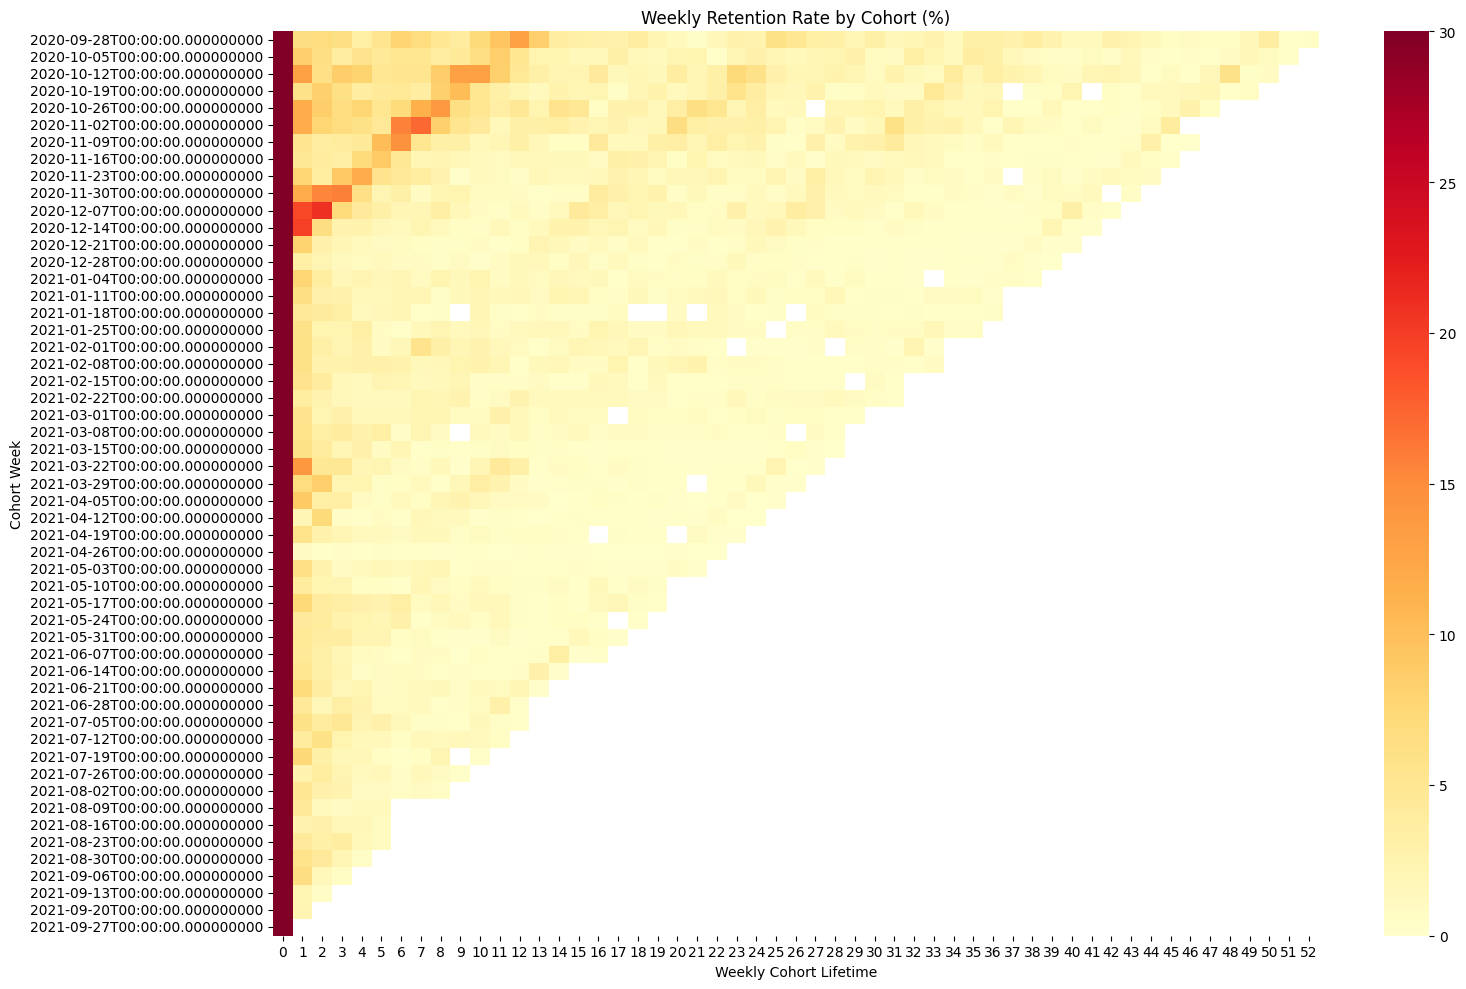

In [37]:
retention_pivot = weekly_active_customers.pivot_table(
    index='cohort_week',
    columns='weekly_cohort_lifetime',
    values='retention_rate'
) * 100

plt.figure(figsize=(16, 10))
sns.heatmap(retention_pivot, annot=False, fmt='.0f', cmap='YlOrRd', vmin=0, vmax=30)
plt.title('Weekly Retention Rate by Cohort (%)')
plt.xlabel('Weekly Cohort Lifetime')
plt.ylabel('Cohort Week')
plt.tight_layout()
plt.show()

### Task 19. Churn rate

Retention nəticəsindən istifadə edərək cumulative churn rate hesablayın, matrix yaradın və heatmap ilə göstərin.

> **Tip:** Cumulative churn rate `1 - retention` kimi hesablana bilər.

In [38]:
weekly_active_customers['cumulative_churn_rate'] = 1 - weekly_active_customers['retention_rate']

churn_pivot = weekly_active_customers.pivot_table(
    index='cohort_week',
    columns='weekly_cohort_lifetime',
    values='cumulative_churn_rate'
) * 100

print(churn_pivot.round(1).iloc[:, :8])

weekly_cohort_lifetime    0     1     2     3     4     5     6     7
cohort_week                                                          
2020-09-28              0.0  93.5  93.3  93.8  96.5  94.8  92.0  93.3
2020-10-05              0.0  91.4  93.6  96.3  94.5  95.6  95.0  95.0
2020-10-12              0.0  87.1  94.0  91.4  92.0  95.1  94.8  94.8
2020-10-19              0.0  94.1  91.7  93.9  96.3  95.6  95.4  96.3
2020-10-26              0.0  88.2  91.4  93.3  92.2  94.9  92.9  88.6
2020-11-02              0.0  88.2  92.3  93.2  94.1  95.5  84.4  82.8
2020-11-09              0.0  94.7  96.3  96.0  95.6  89.8  85.5  94.9
2020-11-16              0.0  95.3  95.9  96.4  93.0  91.2  95.3  98.0
2020-11-23              0.0  92.3  96.1  90.9  88.0  94.6  95.5  96.1
2020-11-30              0.0  88.1  84.6  84.2  93.9  97.8  96.8  99.1
2020-12-07              0.0  80.9  79.1  93.0  95.7  96.9  98.1  98.1
2020-12-14              0.0  80.2  93.5  97.5  97.3  98.3  98.7  97.9
2020-12-21          

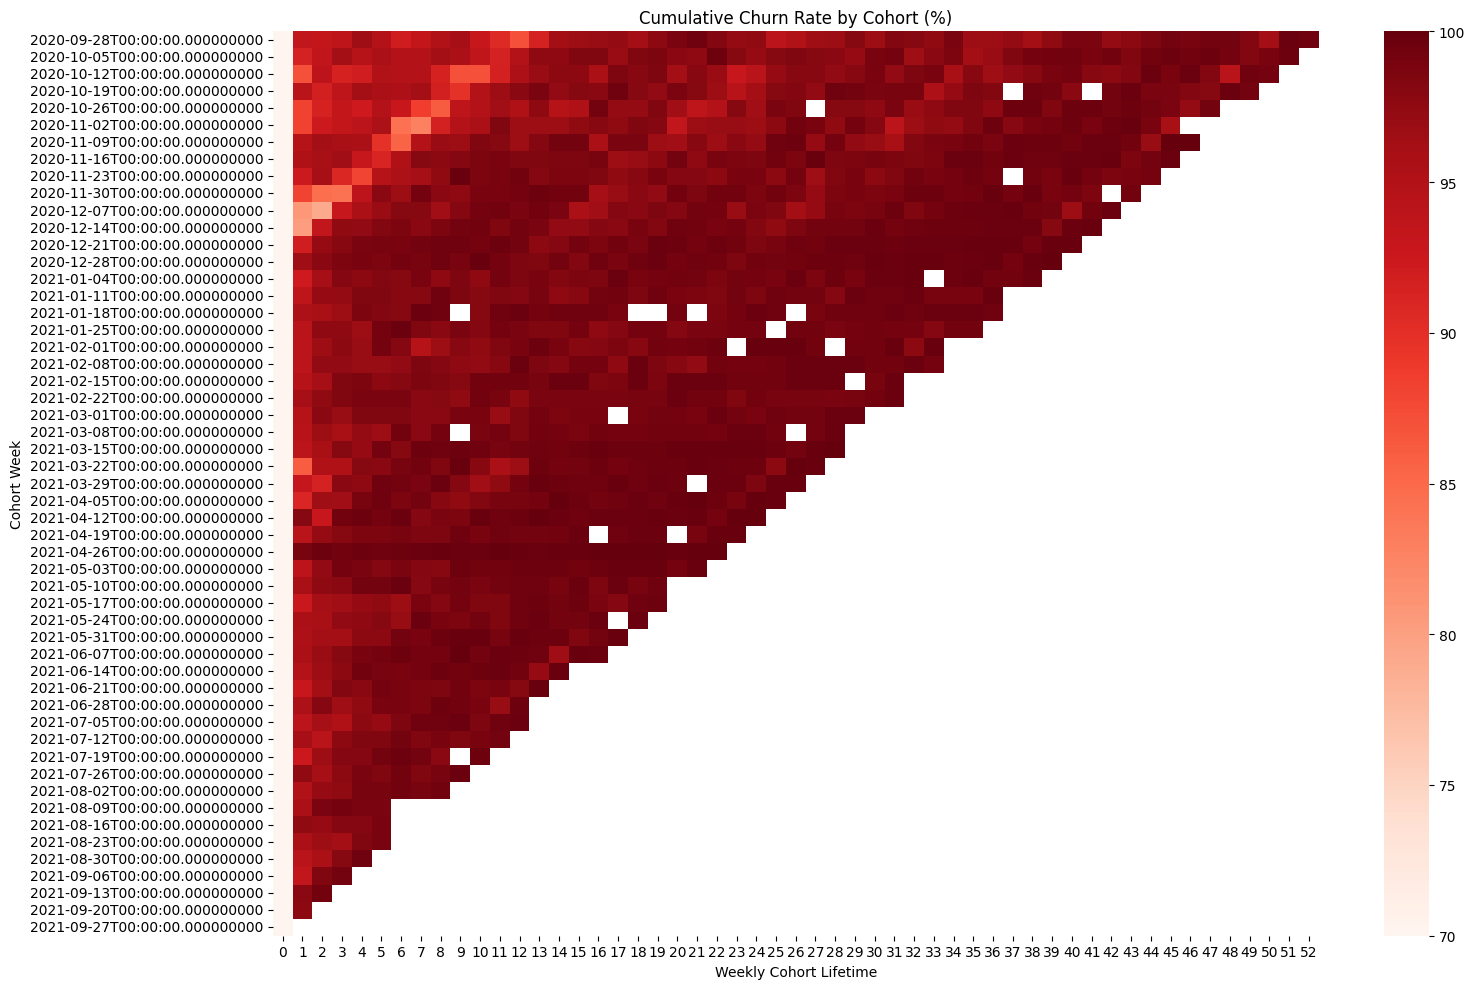

In [39]:

plt.figure(figsize=(16, 10))
sns.heatmap(churn_pivot, annot=False, cmap='Reds', vmin=70, vmax=100)
plt.title('Cumulative Churn Rate by Cohort (%)')
plt.xlabel('Weekly Cohort Lifetime')
plt.ylabel('Cohort Week')
plt.tight_layout()
plt.show()

## 4. Yekun nəticələr

### Task 20. Nəticələrin şərhi
Əsas müşahidələr

1. Cohort ölçüsü mövsümi dəyişkənlikdən çox güclü təsirlənir. 2020-12 cohort-u (64k sifariş, 19.8k müştəri) digərlərindən 3-4 dəfə böyükdür
2. Retention-un ən böyük itkisi ilk təkrar alışdadır. Bütün cohort-larda lifetime 0→1 keçidində müştərilərin 80-95%-i itirilir. Bu tək dəfəlik alıcı (one-time buyer) modelinə işarədir — müştərilər ilk alışdan sonra brendə bağlanmır.

3. Vaxt keçdikcə retention keyfiyyəti zəifləyib. Erkən cohort-larda (2020-09/10) 1-ci həftə retention-u bəzən 15-40%-ə çatırdı, sonrakı cohort-larda (2021-ci il) bu, sabit şəkildə 5-10%-ə enib — yeni gələn müştəri bazasının keyfiyyəti və ya loyallıq təşviqlərinin effektivliyi zamanla azalıb.

4. Qalan "nüvə" seqment sabit, amma çox kiçikdir. Lifetime 3+ retention 1-3% ətrafında sabitləşir — bu kiçik qrup davamlı gəlir mənbəyidir, amma ümumi bazanın cüzi hissəsidir.

5. ARPU sonrakı lifetime-larda etibarsızdır. Kiçik müştəri sayı böyük outlier sifarişlərə həssaslıq yaradır (bəzi xanalarda 30k+ sıçrayış) — yalnız lifetime 0-1 ARPU müqayisə üçün etibarlıdır.

<!-- Cavabınızı burada yazın. -->